In [18]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

pd.set_option('future.no_silent_downcasting', True)

df = pd.read_csv('processed_data.csv', index_col=0)
df.head()

,Age (>35),Accessibility,EdLevel,Employment,Gender,MentalHealth,MainBranch,YearsCode,Country,PrevSalary,Skills,Num_of_skills,Employed
0,0,0,Master,1,1,0,1,7,Sweden,51552,C++;Python;Git;PostgreSQL,4,0
1,0,0,Undergraduate,1,1,0,1,12,Spain,46482,Bash/Shell;HTML/CSS;JavaScript;Node.js;SQL;Typ...,12,1
2,0,0,Master,1,1,0,1,15,Germany,77290,C;C++;Java;Perl;Ruby;Git;Ruby on Rails,7,0
3,0,0,Undergraduate,1,1,0,1,9,Canada,46135,Bash/Shell;HTML/CSS;JavaScript;PHP;Ruby;SQL;Gi...,13,0
4,1,0,PhD,0,1,0,0,40,Singapore,160932,C++;Python,2,0


In [19]:
df = df.drop(columns=['EdLevel','Country','Skills'])

In [20]:
df.head()

,Age (>35),Accessibility,Employment,Gender,MentalHealth,MainBranch,YearsCode,PrevSalary,Num_of_skills,Employed
0,0,0,1,1,0,1,7,51552,4,0
1,0,0,1,1,0,1,12,46482,12,1
2,0,0,1,1,0,1,15,77290,7,0
3,0,0,1,1,0,1,9,46135,13,0
4,1,0,0,1,0,0,40,160932,2,0


In [21]:
y = df['Employed']
X = df.drop(columns=['Employed'], axis=1)

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# create a scaler object
scaler = StandardScaler()

feature_names = X.columns 
gender = X['Gender']

X_train, X_test, y_train, y_test, gender_train, gender_test = train_test_split(
    X, y, gender, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Accuracy for female: 0.7994

Confusion Matrix for Logistic Regression (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,360,112
Actual Not Employed,87,433


Accuracy for male: 0.783

Confusion Matrix for Logistic Regression (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5953,1484
Actual Not Employed,1486,4764



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.76,0.17,0.83,0.24
Male,0.80,0.24,0.76,0.20


Model Accuracy (Logistic Regression): 0.784


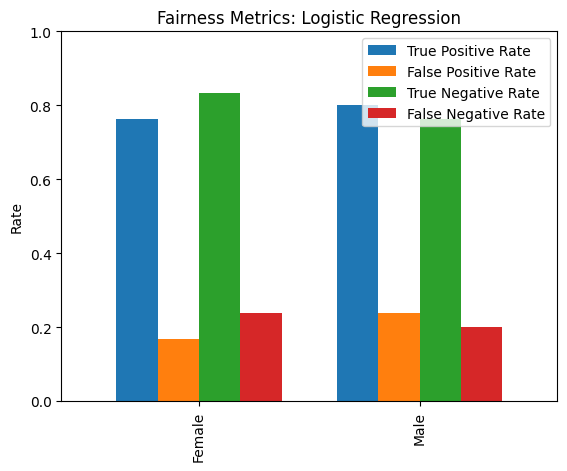

Accuracy for female: 0.7621

Confusion Matrix for Random Forest (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,359,113
Actual Not Employed,123,397


Accuracy for male: 0.7414

Confusion Matrix for Random Forest (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5726,1711
Actual Not Employed,1829,4421



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.76,0.24,0.76,0.24
Male,0.77,0.29,0.71,0.23


Model Accuracy (Random Forest): 0.743


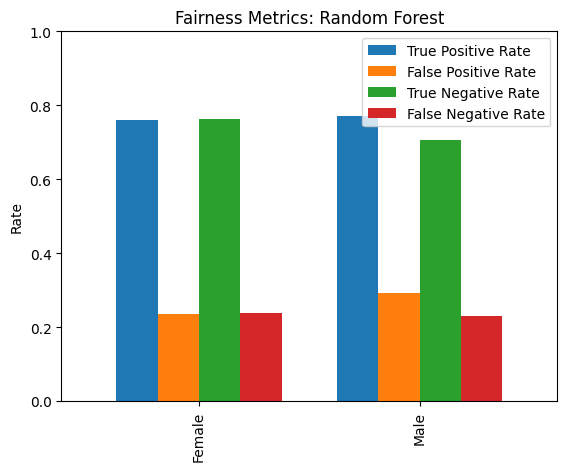

Accuracy for female: 0.8004

Confusion Matrix for Gradient Boosting (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,378,94
Actual Not Employed,104,416


Accuracy for male: 0.7851

Confusion Matrix for Gradient Boosting (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,6182,1255
Actual Not Employed,1687,4563



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.80,0.20,0.80,0.20
Male,0.83,0.27,0.73,0.17


Model Accuracy (Gradient Boosting): 0.786


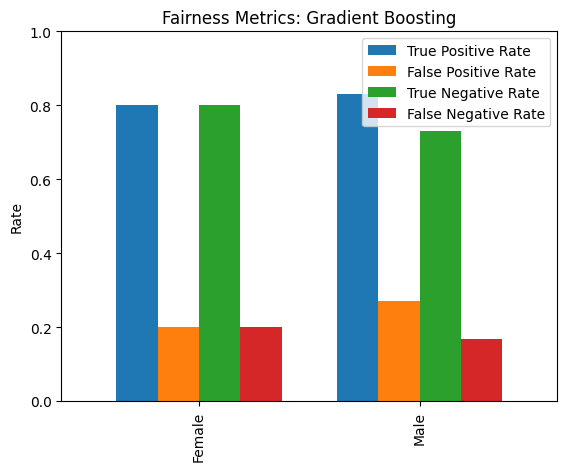

In [23]:
def evaluate_fairness(y_true, y_pred, model_name):
    # Build results dataframe
    # We are using y_test.index to ensure that we pull the correct Gender from the original dataset
    results = pd.DataFrame({
        "y_true": y_true.values, 
        "y_pred": y_pred,
        "Gender": df.loc[y_test.index, "Gender"].values
    })

    # 2) Initialize storage for this specific model
    gender_groups = [0, 1] # 0: Female, 1: Male
    genders_order = ["Female", "Male"]
    confusion_tables = {}
    current_sp = []
    current_tpr = []
    current_fpr = []
    rates = {}

    # 3) Process each gender
    for g in gender_groups:
        subset = results[results["Gender"] == g]
        gender_label = "Female" if g == 0 else "Male"
        
        # Calculate Confusion Matrix
        cm = confusion_matrix(subset["y_true"], subset["y_pred"], labels=[1, 0])
        confusion_tables[gender_label] = pd.DataFrame(
            cm, 
            index=["Actual Employed", "Actual Not Employed"],
            columns=["Predicted Employed", "Predicted Not Employed"]
        )
        
        # Extract values
        tp, fn, fp, tn = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
        
        # Calculate Metrics
        total = tp + tn + fp + fn
        tpr = tp / (tp + fn) if (tp + fn) else np.nan
        fpr = fp / (fp + tn) if (fp + tn) else np.nan

        gender_acc = (tp + tn) / total if total > 0 else 0
        print(f"Accuracy for {gender_label.lower()}: {round(gender_acc, 4)}")
        
        # Store for the global lists (sp_lg, etc.)
        current_sp.append((tp + fp) / total)
        current_tpr.append(tpr)
        current_fpr.append(fpr)

        rates[gender_label] = {
            "True Positive Rate": tpr,
            "False Positive Rate": fpr,
            "True Negative Rate": tn / (tn + fp) if (tn + fp) else np.nan,
            "False Negative Rate": fn / (fn + tp) if (fn + tp) else np.nan
        }
        
        print(f"\nConfusion Matrix for {model_name} (Gender = {gender_label})")
        display(confusion_tables[gender_label])

    # Display Rates Table
    df_rates = pd.DataFrame(rates).T
    print("\nRates:")
    display(df_rates.round(2))

    # Show model accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Model Accuracy ({model_name}): {round(accuracy, 3)}')
    
    #  Visualization
    df_rates = pd.DataFrame(rates).T
    ax = df_rates.plot(kind="bar", width=0.75)
    plt.title(f"Fairness Metrics: {model_name}")
    plt.ylabel("Rate")
    plt.ylim(0, 1)
    plt.show()

    # Return the metrics so you can use them in your fairness measurements
    return current_sp, current_tpr, current_fpr

# Logistic Regression
lr_model = LogisticRegression().fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
sp_lg, TPR_lr, FPR_lr = evaluate_fairness(y_test, y_pred_lr, "Logistic Regression")

# Random Forest
rf_model = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
sp_rf, TPR_rf, FPR_rf = evaluate_fairness(y_test, y_pred_rf, "Random Forest")

# Gradient Boosting
gbc = GradientBoostingClassifier(n_estimators=300, random_state=42).fit(X_train_scaled, y_train)
y_pred_gbc = gbc.predict(X_test_scaled)
sp_gbc, TPR_gbc, FPR_gbc = evaluate_fairness(y_test, y_pred_gbc, "Gradient Boosting")

# Statistical Parity Difference

### $$SPD = Pr(\hat{Y} = 1 \mid D = \text{unprivileged}) - Pr(\hat{Y} = 1 \mid D = \text{privileged})$$

In [24]:
SPD_orig_lg = round(sp_lg[0] - sp_lg[1], 4)
SPD_orig_rf = round(sp_rf[0] - sp_rf[1], 4)
SPD_orig_gbc = round(sp_gbc[0] - sp_gbc[1], 4)
print(f'Logistic Regression -> {SPD_orig_lg} \n Random Forest -> {SPD_orig_rf} \n Gradient Boosting -> {SPD_orig_gbc}')

Logistic Regression -> -0.0929 
 Random Forest -> -0.0661 
 Gradient Boosting -> -0.089


# Disparate Impact
### $$DI = \frac{Pr(\hat{Y} = 1 \mid D = \text{unprivileged})}{Pr(\hat{Y} = 1 \mid D = \text{privileged})}$$ $$DI = \frac{\text{Selection Rate for Females}}{\text{Selection Rate for Males}}$$

In [25]:
# SP for Logistic Regression
print(f'Logistic Regression -> {round(sp_lg[0] / sp_lg[1], 4)} \n Random Forest -> {round(sp_rf[0] / sp_rf[1], 4)} \n Gradient Boosting -> {round(sp_gbc[0] / sp_gbc[1], 4)}')

Logistic Regression -> 0.8291 
 Random Forest -> 0.8803 
 Gradient Boosting -> 0.8451


# Equal Opportunity
### $$\text{Equal Opportunity} = (TPR_{\text{Female}} - TPR_{\text{Male}})$$

In [26]:
print(f'Logistic Regression -> {round(TPR_lr[0] - TPR_lr[1], 4)} \nRandom Forest -> {round(TPR_rf[0] - TPR_rf[1], 4)} \nGradient Boosting -> {round(TPR_gbc[0] - TPR_gbc[1], 4)}')

Logistic Regression -> -0.0377 
Random Forest -> -0.0093 
Gradient Boosting -> -0.0304


# Equalized Odds

### $$\text{Equalized Odds} = \frac{(TPR_{\text{Female}} - TPR_{\text{Male}}) + (FPR_{\text{Female}} - FPR_{\text{Male}})}{2}$$

In [27]:
print(f'Logistic Regression -> {round(((TPR_lr[0] - TPR_lr[1]) + (FPR_lr[0] - FPR_lr[1])) / 2, 4)} \nRandom Forest -> {round(((TPR_rf[0] - TPR_rf[1]) + (FPR_rf[0] - FPR_rf[1])) / 2, 4)} \nGradient Boosting -> {round(((TPR_gbc[0] - TPR_gbc[1]) + (FPR_gbc[0] - FPR_gbc[1])) / 2, 4)}')

Logistic Regression -> -0.0541 
Random Forest -> -0.0327 
Gradient Boosting -> -0.0502


# Bias Mitigation

## Pre-Processing (Removing Gender Attribute)  'Fairness through Blindness'.

In [28]:
X_train_blind = np.delete(X_train_scaled, 3, axis=1)
X_test_blind = np.delete(X_test_scaled, 3, axis=1)

Accuracy for female: 0.8004

Confusion Matrix for Logistic Regression (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,368,104
Actual Not Employed,94,426


Accuracy for male: 0.7828

Confusion Matrix for Logistic Regression (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5944,1493
Actual Not Employed,1480,4770



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.78,0.18,0.82,0.22
Male,0.80,0.24,0.76,0.20


Model Accuracy (Logistic Regression): 0.784


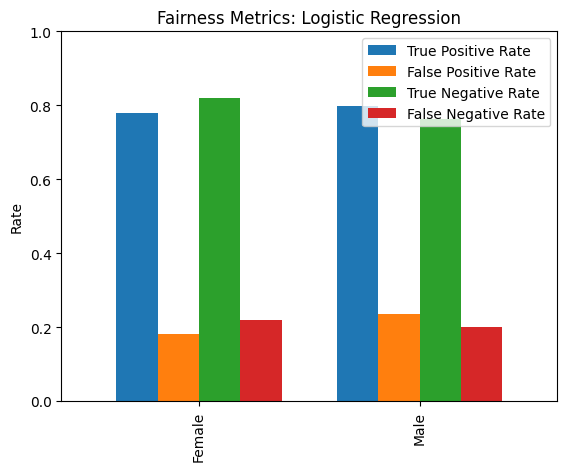

Accuracy for female: 0.7571

Confusion Matrix for Random Forest (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,347,125
Actual Not Employed,116,404


Accuracy for male: 0.7388

Confusion Matrix for Random Forest (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5695,1742
Actual Not Employed,1833,4417



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.74,0.22,0.78,0.26
Male,0.77,0.29,0.71,0.23


Model Accuracy (Random Forest): 0.74


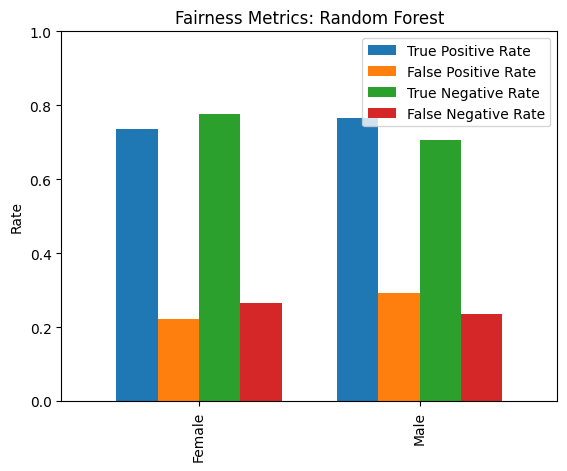

Accuracy for female: 0.8065

Confusion Matrix for Gradient Boosting (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,384,88
Actual Not Employed,104,416


Accuracy for male: 0.7848

Confusion Matrix for Gradient Boosting (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,6167,1270
Actual Not Employed,1676,4574



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.81,0.20,0.80,0.19
Male,0.83,0.27,0.73,0.17


Model Accuracy (Gradient Boosting): 0.786


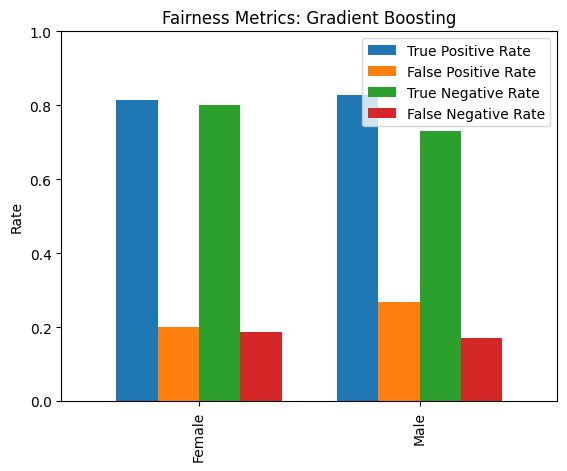

In [29]:
def evaluate_fairness(y_true, y_pred, model_name):
    # Build results dataframe
    # We are using y_test.index to ensure that we pull the correct Gender from the original dataset
    results = pd.DataFrame({
        "y_true": y_true.values, 
        "y_pred": y_pred,
        "Gender": df.loc[y_test.index, "Gender"].values
    })

    # 2) Initialize storage for this specific model
    gender_groups = [0, 1] # 0: Female, 1: Male
    genders_order = ["Female", "Male"]
    confusion_tables = {}
    current_sp = []
    current_tpr = []
    current_fpr = []
    rates = {}

    # 3) Process each gender
    for g in gender_groups:
        subset = results[results["Gender"] == g]
        gender_label = "Female" if g == 0 else "Male"
        
        # Calculate Confusion Matrix
        cm = confusion_matrix(subset["y_true"], subset["y_pred"], labels=[1, 0])
        confusion_tables[gender_label] = pd.DataFrame(
            cm, 
            index=["Actual Employed", "Actual Not Employed"],
            columns=["Predicted Employed", "Predicted Not Employed"]
        )
        
        # Extract values
        tp, fn, fp, tn = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
        
        # Calculate Metrics
        total = tp + tn + fp + fn
        tpr = tp / (tp + fn) if (tp + fn) else np.nan
        fpr = fp / (fp + tn) if (fp + tn) else np.nan

        gender_acc = (tp + tn) / total if total > 0 else 0
        print(f"Accuracy for {gender_label.lower()}: {round(gender_acc, 4)}")
        
        # Store for the global lists (sp_lg, etc.)
        current_sp.append((tp + fp) / total)
        current_tpr.append(tpr)
        current_fpr.append(fpr)

        rates[gender_label] = {
            "True Positive Rate": tpr,
            "False Positive Rate": fpr,
            "True Negative Rate": tn / (tn + fp) if (tn + fp) else np.nan,
            "False Negative Rate": fn / (fn + tp) if (fn + tp) else np.nan
        }
        
        print(f"\nConfusion Matrix for {model_name} (Gender = {gender_label})")
        display(confusion_tables[gender_label])

    # Display Rates Table
    df_rates = pd.DataFrame(rates).T
    print("\nRates:")
    display(df_rates.round(2))

    # Show model accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Model Accuracy ({model_name}): {round(accuracy, 3)}')
    
    #  Visualization
    df_rates = pd.DataFrame(rates).T
    ax = df_rates.plot(kind="bar", width=0.75)
    plt.title(f"Fairness Metrics: {model_name}")
    plt.ylabel("Rate")
    plt.ylim(0, 1)
    plt.show()

    # Return the metrics so you can use them in your fairness measurements
    return current_sp, current_tpr, current_fpr

# Logistic Regression
lr_model = LogisticRegression(random_state=42).fit(X_train_blind, y_train)
y_pred_lr = lr_model.predict(X_test_blind)
sp_lg, TPR_lr, FPR_lr = evaluate_fairness(y_test, y_pred_lr, "Logistic Regression")

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_blind, y_train)
y_pred_rf = rf_model.predict(X_test_blind)
sp_rf, TPR_rf, FPR_rf = evaluate_fairness(y_test, y_pred_rf, "Random Forest")

# Gradient Boosting
gbc = GradientBoostingClassifier(n_estimators=100, random_state=42).fit(X_train_blind, y_train)
y_pred_gbc = gbc.predict(X_test_blind)
sp_gbc, TPR_gbc, FPR_gbc = evaluate_fairness(y_test, y_pred_gbc, "Gradient Boosting")

# Statistical Parity Difference

### $$SPD = Pr(\hat{Y} = 1 \mid D = \text{unprivileged}) - Pr(\hat{Y} = 1 \mid D = \text{privileged})$$

In [30]:
SPD_new_lg = round(sp_lg[0] - sp_lg[1], 4)
SPD_new_rf = round(sp_rf[0] - sp_rf[1], 4)
SPD_new_gbc = round(sp_gbc[0] - sp_gbc[1], 4)
print(f'Logistic Regression -> {SPD_new_lg} \n Random Forest -> {SPD_new_rf} \n Gradient Boosting -> {SPD_new_gbc}')

Logistic Regression -> -0.0767 
 Random Forest -> -0.0833 
 Gradient Boosting -> -0.0811


# Disparate Impact
### $$DI = \frac{Pr(\hat{Y} = 1 \mid D = \text{unprivileged})}{Pr(\hat{Y} = 1 \mid D = \text{privileged})}$$ $$DI = \frac{\text{Selection Rate for Females}}{\text{Selection Rate for Males}}$$

In [31]:
print(f'Logistic Regression -> {round(sp_lg[0] / sp_lg[1], 4)} \n Random Forest -> {round(sp_rf[0] / sp_rf[1], 4)} \n Gradient Boosting -> {round(sp_gbc[0] / sp_gbc[1], 4)}')

Logistic Regression -> 0.8586 
 Random Forest -> 0.8486 
 Gradient Boosting -> 0.8585


# Equal Opportunity
### $$\text{Equal Opportunity} = (TPR_{\text{Female}} - TPR_{\text{Male}})$$

In [32]:
print(f'Logistic Regression -> {round(TPR_lr[0] - TPR_lr[1], 4)} \nRandom Forest -> {round(TPR_rf[0] - TPR_rf[1], 4)} \nGradient Boosting -> {round(TPR_gbc[0] - TPR_gbc[1], 4)}')

Logistic Regression -> -0.0196 
Random Forest -> -0.0306 
Gradient Boosting -> -0.0157


# Equalized Odds

### $$\text{Equalized Odds} = \frac{(TPR_{\text{Female}} - TPR_{\text{Male}}) + (FPR_{\text{Female}} - FPR_{\text{Male}})}{2}$$

In [33]:
print(f'Logistic Regression -> {round(((TPR_lr[0] - TPR_lr[1]) + (FPR_lr[0] - FPR_lr[1])) / 2, 4)} \nRandom Forest -> {round(((TPR_rf[0] - TPR_rf[1]) + (FPR_rf[0] - FPR_rf[1])) / 2, 4)} \nGradient Boosting -> {round(((TPR_gbc[0] - TPR_gbc[1]) + (FPR_gbc[0] - FPR_gbc[1])) / 2, 4)}')

Logistic Regression -> -0.0378 
Random Forest -> -0.0504 
Gradient Boosting -> -0.0419
